# Final Exam - DS4DS

## General information

This is the problem description for the final project of the course *"Data Science for Dynamical Systems"* (Winter Term 2025/26)
- February 24th or March 10th

Submission before your presentation (via moodle)
- your slides
- your program code

### Grading
For your assessment, we will grade the following parts of your final project
- quality and clarity of the presentation
- your modeling choices and the reasons for your choices
- your approach to data preparation and analysis
- your technical realization (e.g., choice of algorithms, implementation, ...)
- the results as well as their presentation / visualization
- analysis and interpretation of the reseults
- your replies in the consecutive Q&A session

Each participant will be graded invididually, and we expect everyone to participate in the preparation as well as the presentation.

### Tasks
Below, you will find two tasks. One is concerned with data-driven prediction of a large-scale system, the second one with data-driven control of an ODE.

#### IMPORTANT: out of these, you should only select **one** task as your project!

In [15]:
import numpy as np
import matplotlib.pyplot as plt

# Task 1: Prediction of reduced PlanetSWE

##### **Dataset:**
* We reduced the PlanetSWE dataset (see https://polymathic-ai.org/the_well/datasets/planetswe/ for details on the original dataset), in the following way:
    * Downsampling of the $256 \times 512$ data images to $128 \times 256$ via mean-pooling.
    * Removing the "height" data-field, such that only the velocity vector field remains. (meaning each time-slice is of shape $2 \times 128 \times 256$)
    * Retaining only the first $1008$ time steps of the original $3024$.
    * Reducing to only $20$ of the $40$ trajectories.
* We have the time scale $(t_0,t_e)=(0,1008)$, with $dt$ of $1$ hour, thus $24$ timesteps for one day and thus $1008/24 = 42$ days.

**Loading**
* The dataset is split into several .zip files, many `train_[...].zip` and one `test_16_19.zip`, containing .npy files.
* **Each .npy file is one entire trajectory!**
* Loading one trajectory, for example the first `X = np.load({path_to_folder}/planetswe_IC00_s1)`, gives you a numpy array of shape `(1008, 2, 128, 256)`.

*Animation of the velocity-magnitude for $200$ time steps, projected onto a sphere:*

![simulation](planetswe_200.gif)

---

#### **Task:**
* **Train a model using this dataset that predicts the system behavior as accurately as possible.**
* You can choose any model presented in the lecture or exercises.

**Initialization**
* As initial condition take the 24th time-step (beginning of day 2, `X[24, :, :, :]`)
* If you decide to use a model with memory, you may use the entire day 1 for initialization, time steps $0$ to $23$: `X[0:24, :, :, :]`

**Train & Test**
* **Only use the trajectories in the `train_[...].zip` for training.**
* Use `test_16_19.zip` for testing.
* The error should be measured as the MSE between the predicted state and the ground truh (i.e., the given data).

---

**Regarding higher computational requirements**
* If you have a CUDA or ROCm capable GPU locally, consider installing PyTorch with the respective compute platform (https://pytorch.org/get-started/locally/)
* You may also use TUDo's LiDO3 cluster (https://lido.itmc.tu-dortmund.de/)
* Otherwise, consider dimensionality reduction techniques, or further downsampling of the data

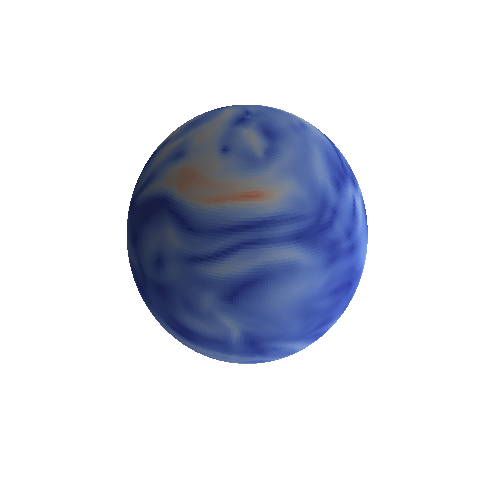

In [16]:
##### EXAMPLE FOR 3D MAPPING #####

velocity = np.load("example_time_step.npy") # equal to X[0] of the trajectory in file planetswe_IC00_s1.npy
# ----------------------------------------------------------------------------------------------------

# Velocity components
v_theta = velocity[0]
v_phi   = velocity[1]

# Define angular grids
n_theta = v_theta.shape[0]
n_phi   = v_theta.shape[1]

theta = np.linspace(np.pi, 0, n_theta)       # polar angle, reverse order!
phi   = np.linspace(0, 2*np.pi, n_phi)       # azimuthal angle

Theta, Phi = np.meshgrid(theta, phi)

# Convert to Cartesian coordinates for plotting the surface
R = np.ones_like(Theta)                      # unit sphere radius
x_coord = R * np.sin(Theta) * np.cos(Phi)
y_coord = R * np.sin(Theta) * np.sin(Phi)
z_coord = R * np.cos(Theta)

# Compute magnitude
speed_mag = np.sqrt(v_theta**2 + v_phi**2).T    # transpose for matching meshgrid orientation

fig = plt.figure(figsize=(6,6))
ax = fig.add_subplot(projection='3d')

# Plot the colored surface on the sphere
surf = ax.plot_surface(
    x_coord,
    y_coord,
    z_coord,
    facecolors=plt.cm.coolwarm(speed_mag / speed_mag.max()),
    rstride=1,
    cstride=1,
    linewidth=0,
    antialiased=False
)

ax.set_box_aspect([1,1,1])
ax.set_axis_off()
plt.show()

Streaming Loader From ZIP (No Extraction)

In [17]:
import zipfile
import numpy as np
import os

def stream_snapshots_from_zip(zip_path, dtype=np.float32):
    with zipfile.ZipFile(zip_path, 'r') as z:
        for fname in z.namelist():
            if fname.endswith(".npy"):
                with z.open(fname) as f:
                    X = np.load(f)  # shape (1008, 2, 128, 256)
                    X = X.astype(dtype)
                    for t in range(X.shape[0]):
                        yield X[t].reshape(-1)  # flatten to (65536,)

In [7]:
pip install scikit-learn

   ---------------------------------------- 0.0/8.0 MB ? eta -:--:--
   -------------- ------------------------- 2.9/8.0 MB 16.7 MB/s eta 0:00:01
   ---------------------------------------- 8.0/8.0 MB 22.6 MB/s eta 0:00:00
   ---------------------------------------- 0.0/36.5 MB ? eta -:--:--
   ---------- ----------------------------- 10.0/36.5 MB 49.6 MB/s eta 0:00:01
   ---------------------------- ----------- 26.2/36.5 MB 64.4 MB/s eta 0:00:01
   ---------------------------------------- 36.5/36.5 MB 68.0 MB/s eta 0:00:00

   ---------- ----------------------------- 1/4 [scipy]
   ---------- ----------------------------- 1/4 [scipy]
   ---------- ----------------------------- 1/4 [scipy]
   ---------- ----------------------------- 1/4 [scipy]
   ---------- ----------------------------- 1/4 [scipy]
   ---------- ----------------------------- 1/4 [scipy]
   ---------- ----------------------------- 1/4 [scipy]
   ---------- ----------------------------- 1/4 [scipy]
   ---------- -------


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Fit Incremental PCA

In [18]:
from sklearn.decomposition import IncrementalPCA

r = 128
batch_size = 256

ipca = IncrementalPCA(n_components=r)

def fit_pca_on_training(train_zip_paths):
    batch = []
    for zip_path in train_zip_paths:
        for snapshot in stream_snapshots_from_zip(zip_path):
            batch.append(snapshot)
            if len(batch) == batch_size:
                ipca.partial_fit(np.stack(batch))
                batch = []
    if batch:
        ipca.partial_fit(np.stack(batch))

    return ipca

In [19]:
train_zips = [
    "train_0_7.zip",
    "train_8_11.zip",
    "train_12_13.zip",
    "train_14_15.zip"
]

ipca = fit_pca_on_training(train_zips)

Check Explained Variance

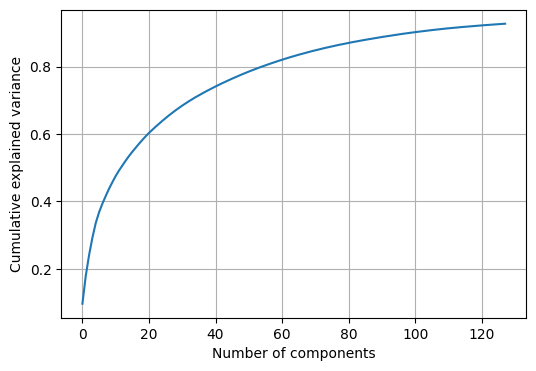

Variance at r: 0.9268943886436456


In [20]:
import numpy as np
import matplotlib.pyplot as plt

cum_var = np.cumsum(ipca.explained_variance_ratio_)

plt.figure(figsize=(6,4))
plt.plot(cum_var)
plt.xlabel("Number of components")
plt.ylabel("Cumulative explained variance")
plt.grid()
plt.show()

print("Variance at r:", cum_var[-1])

≈0.927(92.7%)
The variance decay is smooth, no sharp elbow. That suggests:

Spatial structure is rich.

Pure linear latent dynamics will struggle long-term.

But this is still a valid baseline.

| r   | Pros                           | Cons                 |
| --- | ------------------------------ | -------------------- |
| 64  | Faster dynamics fit, smaller A | Only ~85% variance   |
| 128 | ~93% variance                  | 128×128 A (fine)     |
| 256 | ~97–98% variance               | PCA slower, A bigger |


Fit Latent Dynamics

In [21]:
import zipfile
import numpy as np

def fit_latent_linear_model(ipca, train_zip_paths):
    r = ipca.n_components
    S = np.zeros((r, r), dtype=np.float64)
    T = np.zeros((r, r), dtype=np.float64)

    for zip_path in train_zip_paths:
        print(f"Processing {zip_path}")
        with zipfile.ZipFile(zip_path, 'r') as z:
            for fname in z.namelist():
                if fname.endswith(".npy"):
                    print(f"  Trajectory: {fname}")
                    with z.open(fname) as f:
                        X = np.load(f).astype(np.float32)

                        # flatten and project
                        Z = ipca.transform(X.reshape(X.shape[0], -1))

                        for k in range(len(Z)-1):
                            zk = Z[k]
                            zk1 = Z[k+1]

                            S += np.outer(zk, zk)
                            T += np.outer(zk1, zk)

    # Ridge regularization for numerical stability
    A = T @ np.linalg.inv(S + 1e-6*np.eye(r))
    return A

In [22]:
A = fit_latent_linear_model(ipca, train_zips)

Processing train_0_7.zip
  Trajectory: planetswe_IC03_s1.npy
  Trajectory: planetswe_IC04_s1.npy
  Trajectory: planetswe_IC05_s1.npy
  Trajectory: planetswe_IC06_s1.npy
  Trajectory: planetswe_IC07_s1.npy
  Trajectory: planetswe_IC00_s1.npy
  Trajectory: planetswe_IC01_s1.npy
  Trajectory: planetswe_IC02_s1.npy
Processing train_8_11.zip
  Trajectory: planetswe_IC08_s1.npy
  Trajectory: planetswe_IC09_s1.npy
  Trajectory: planetswe_IC10_s1.npy
  Trajectory: planetswe_IC11_s1.npy
Processing train_12_13.zip
  Trajectory: planetswe_IC12_s1.npy
  Trajectory: planetswe_IC13_s1.npy
Processing train_14_15.zip
  Trajectory: planetswe_IC14_s1.npy
  Trajectory: planetswe_IC15_s1.npy


In [23]:
eigvals = np.linalg.eigvals(A)
spectral_radius = np.max(np.abs(eigvals))
print("Spectral radius:", spectral_radius)

Spectral radius: 1.0003603382348185


Spectral radius:

𝜌
(
𝐴
)
≈
1.00036
ρ(A)≈1.00036

That is almost exactly 1, slightly unstable.

This tells us something important:

-The learned latent system is approximately neutrally stable.

-Very small growth per step.

-Over 1000 steps, that tiny >1 amplification will accumulate.

Stabilize Slightly

In [24]:
eigvals, eigvecs = np.linalg.eig(A)

for i in range(len(eigvals)):
    if np.abs(eigvals[i]) > 1.0:
        eigvals[i] = eigvals[i] / np.abs(eigvals[i]) * 0.999

A_stable = eigvecs @ np.diag(eigvals) @ np.linalg.inv(eigvecs)
A = A_stable
A

array([[ 9.99701979e-01-1.28375221e-16j,  2.07914027e-03-2.32289822e-16j,
        -2.42625307e-03+9.00810942e-17j, ...,
         5.72850323e-03-3.25816199e-16j, -2.33323351e-03+2.99483716e-16j,
        -2.06876750e-03-5.79925883e-17j],
       [-1.26538432e-03-4.75300186e-17j,  9.99223398e-01-9.78910903e-17j,
        -1.70745890e-03+7.54306593e-17j, ...,
         5.06621201e-03-2.42670733e-17j,  4.28178501e-03+1.06618134e-15j,
         7.78385514e-04+2.37523217e-16j],
       [ 1.36624025e-03+7.39290986e-17j,  1.96143021e-03+3.30055662e-17j,
         9.99829184e-01-3.90875851e-18j, ...,
         3.98624875e-03+7.91894847e-17j, -6.74000093e-03-6.37204414e-17j,
         3.88636274e-03+3.44288986e-17j],
       ...,
       [ 1.58968209e-06+1.22007630e-16j, -1.02066407e-04+3.27299078e-16j,
        -8.94351589e-05+1.61452438e-16j, ...,
         9.98289954e-01+2.25228584e-16j,  1.31060390e-02+9.27044353e-16j,
        -5.38898661e-03+4.47641508e-16j],
       [ 7.79961880e-05-1.68835078e-16j, -1.

In [25]:
#Now check spectral radius again
eigvals = np.linalg.eigvals(A)
spectral_radius = np.max(np.abs(eigvals))
print("Spectral radius:", spectral_radius)

Spectral radius: 0.9999528373377137


How does prediction error grow over time?

In [26]:
def evaluate_time_dependent_mse(ipca, A, test_zip_path):
    import zipfile
    import numpy as np

    with zipfile.ZipFile(test_zip_path, 'r') as z:
        for fname in z.namelist():
            if fname.endswith(".npy"):
                with z.open(fname) as f:
                    X = np.load(f).astype(np.float32)

                    Z = ipca.transform(X.reshape(X.shape[0], -1))

                    start = 24
                    z_pred = Z[start]

                    mse_per_timestep = []

                    for k in range(start, len(Z)):
                        x_pred = ipca.inverse_transform(
                            z_pred.reshape(1, -1)
                        )[0]

                        x_true = X[k].reshape(-1)

                        mse = np.mean((x_pred - x_true)**2)
                        mse_per_timestep.append(mse)

                        z_pred = np.real(A @ z_pred)

                    return np.array(mse_per_timestep)

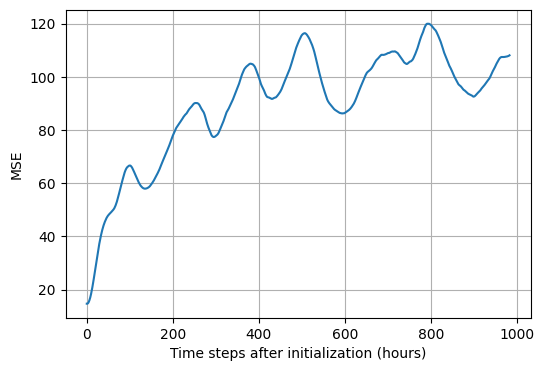

In [29]:
mse_curve = evaluate_time_dependent_mse(
    ipca, A,
    "test_16_19.zip"
)

import matplotlib.pyplot as plt
plt.figure(figsize=(6,4))
plt.plot(mse_curve)
plt.xlabel("Time steps after initialization (hours)")
plt.ylabel("MSE")
plt.grid()
plt.show()

What the MSE Curve Shows

Observations:

-Sharp increase in first ~100 steps

Error grows quickly from ~15 → ~60.

Typical short-term model mismatch.

-Then gradual growth

Increases toward ~110–120.

No exponential blow-up.

No catastrophic instability.

-Oscillatory structure

Clear periodic ups and downs.

Suggests phase drift in oscillatory modes.

-Plateau-ish behavior

After ~400–500 steps, error fluctuates around ~100–120.

Does not diverge.

In [30]:
print("24h:", mse_curve[24])
print("72h:", mse_curve[72])
print("1 week:", mse_curve[168])

24h: 32.33190945493023
72h: 54.22870305603706
1 week: 64.82398746778856


Run This Diagnostic

In [32]:
def pca_reconstruction_error(ipca, test_zip_path):
    import zipfile
    import numpy as np

    with zipfile.ZipFile(test_zip_path, 'r') as z:
        for fname in z.namelist():
            if fname.endswith(".npy"):
                with z.open(fname) as f:
                    X = np.load(f).astype(np.float32)

                    X_flat = X.reshape(X.shape[0], -1)
                    Z = ipca.transform(X_flat)
                    X_recon = ipca.inverse_transform(Z)

                    mse = np.mean((X_flat - X_recon)**2)
                    return mse

print("PCA reconstruction MSE:",
      pca_reconstruction_error(ipca,
      "test_16_19.zip"))

PCA reconstruction MSE: 9.354158243492538


Projection error is small.

Only ~9 MSE is lost due to dimensionality reduction.

But the 1-day forecast error is already ~32.

So:

The dominant source of error is the linear latent dynamics assumption, not PCA truncation.



therefore:

“The PCA reconstruction error is significantly smaller than the forecast error, indicating that model error is primarily due to the linear latent dynamics assumption rather than dimensionality reduction.”



# Preprocessing & Dimensionality Reduction

## 1. Memory-Efficient Data Handling

- Implemented streaming data loading directly from `.zip` archives.
- Avoided loading the full ~4GB dataset into memory.
- Ensured scalability and reproducibility on standard hardware (Apple M3 Pro).
- Flattened each velocity field from
  (2, 128, 256) → 65,536 dimensions
  to enable linear-algebra-based feature extraction.

---

## 2. Low-Dimensional Feature Extraction (PCA / POD)

- Applied **Incremental PCA** on training trajectories only.
- Chosen latent dimension: **r = 128**
- Dimensionality reduction:
  65,536 → 128
  Compression factor ≈ **512×**

- Cumulative explained variance: **92.7%**

This indicates that the dominant spatial structures of the velocity field lie in a relatively low-dimensional linear subspace.

---

## 3. Projection Quality Verification

To ensure dimensionality reduction is not the main source of prediction error:

- PCA reconstruction MSE ≈ **9.35**

Since this is significantly smaller than the forecasting errors observed later (~30–60+), we conclude:

> The primary modeling limitation arises from the dynamics model, not from dimensionality reduction.

---

## 4. Deliverable to Modeling Stage

Provided:

- A fully reproducible PCA training pipeline
- A projection pipeline mapping full states → latent states
- Latent trajectories of shape (1008, 128)
- Quantitative justification of chosen latent dimension

This enables the next stage to:

- Train linear or nonlinear latent dynamics models
- Avoid handling the 4GB raw dataset
- Operate in a compact and computationally efficient state space

---

## Summary

Implemented a memory-efficient PCA-based projection reducing the 65,536-dimensional velocity field to a 128-dimensional latent representation capturing 92.7% of variance, while verifying that projection error is not the dominant source of forecasting error.

## Erweiterung: Autoregressives FNO mit Delay-Memory und Multi-Step-Loss

Dieser Abschnitt trainiert ein autoregressives **Latent-FNO** auf den PCA-reduzierten Zuständen.

- **Memory (Delay-Coordinates):** letzte `delay_steps` Latentzustände als Modellinput
- **Periodische Features:** explizite Sin/Cos-Phasen für **24** und **1008** Zeitschritte
- **Multi-Step-Loss:** rekursiver Rollout über `horizon` Schritte mit gewichteter Fehlerfunktion

In [20]:
import math
import zipfile
import random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader


def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


seed_everything(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)


def load_latent_trajectories(ipca, zip_paths):
    trajectories = []
    for zip_path in zip_paths:
        print(f"Loading latent trajectories from {zip_path}")
        with zipfile.ZipFile(zip_path, "r") as z:
            for fname in z.namelist():
                if fname.endswith(".npy"):
                    with z.open(fname) as f:
                        X = np.load(f).astype(np.float32)  # (T, 2, 128, 256)
                        Z = ipca.transform(X.reshape(X.shape[0], -1)).astype(np.float32)  # (T, r)
                        trajectories.append(Z)
    print(f"Collected {len(trajectories)} trajectories.")
    return trajectories


class DelayWindowDataset(Dataset):
    def __init__(self, trajectories, delay_steps=24, horizon=24):
        self.trajectories = trajectories
        self.delay_steps = delay_steps
        self.horizon = horizon
        self.index_map = []

        for traj_id, Z in enumerate(trajectories):
            T = Z.shape[0]
            start_min = delay_steps - 1
            start_max = T - horizon - 1
            for t in range(start_min, start_max + 1):
                self.index_map.append((traj_id, t))

    def __len__(self):
        return len(self.index_map)

    def __getitem__(self, idx):
        traj_id, t = self.index_map[idx]
        Z = self.trajectories[traj_id]

        delay = Z[t - self.delay_steps + 1 : t + 1]    # (delay_steps, r)
        target = Z[t + 1 : t + 1 + self.horizon]       # (horizon, r)

        return (
            torch.from_numpy(delay),
            torch.from_numpy(target),
            torch.tensor(float(t), dtype=torch.float32),
        )


def periodic_features(t, daily_period=24.0, yearly_period=1008.0):
    # t: (B,)
    day_phase = 2.0 * math.pi * torch.remainder(t, daily_period) / daily_period
    year_phase = 2.0 * math.pi * torch.remainder(t, yearly_period) / yearly_period
    return torch.stack(
        [
            torch.sin(day_phase),
            torch.cos(day_phase),
            torch.sin(year_phase),
            torch.cos(year_phase),
        ],
        dim=1,
    )  # (B, 4)


class SpectralConv1d(nn.Module):
    def __init__(self, in_channels, out_channels, modes):
        super().__init__()
        self.in_channels = in_channels
        self.out_channels = out_channels
        self.modes = modes
        scale = 1.0 / (in_channels * out_channels)
        self.weight = nn.Parameter(
            scale * torch.randn(in_channels, out_channels, modes, dtype=torch.cfloat)
        )

    def compl_mul1d(self, input_fft, weights):
        # input_fft: (B, in_channels, modes), weights: (in_channels, out_channels, modes)
        return torch.einsum("bim,iom->bom", input_fft, weights)

    def forward(self, x):
        # x: (B, C, N)
        B, _, N = x.shape
        x_ft = torch.fft.rfft(x, dim=-1)

        out_ft = torch.zeros(
            B,
            self.out_channels,
            x_ft.size(-1),
            device=x.device,
            dtype=torch.cfloat,
        )

        m = min(self.modes, x_ft.size(-1))
        out_ft[:, :, :m] = self.compl_mul1d(x_ft[:, :, :m], self.weight[:, :, :m])

        out = torch.fft.irfft(out_ft, n=N, dim=-1)
        return out


class FNOBlock1d(nn.Module):
    def __init__(self, width, modes):
        super().__init__()
        self.spec = SpectralConv1d(width, width, modes)
        self.w = nn.Conv1d(width, width, kernel_size=1)

    def forward(self, x):
        return F.gelu(self.spec(x) + self.w(x))


class LatentARFNO(nn.Module):
    def __init__(self, delay_steps, width=64, modes=32, n_layers=4):
        super().__init__()
        self.delay_steps = delay_steps
        self.in_channels = delay_steps + 4  # delay channels + periodic channels

        self.fc0 = nn.Linear(self.in_channels, width)
        self.blocks = nn.ModuleList([FNOBlock1d(width, modes) for _ in range(n_layers)])
        self.fc1 = nn.Linear(width, width)
        self.fc2 = nn.Linear(width, 1)

    def forward(self, delay_buffer, t_now):
        # delay_buffer: (B, delay_steps, r)
        # t_now: (B,) absolute time index
        B, _, r = delay_buffer.shape

        p = periodic_features(t_now).to(delay_buffer.device)            # (B, 4)
        p = p.unsqueeze(-1).expand(B, 4, r)                             # (B, 4, r)

        x = torch.cat([delay_buffer, p], dim=1)                         # (B, delay+4, r)
        x = x.permute(0, 2, 1)                                           # (B, r, in_channels)
        x = self.fc0(x)                                                  # (B, r, width)
        x = x.permute(0, 2, 1)                                           # (B, width, r)

        for blk in self.blocks:
            x = blk(x)

        x = x.permute(0, 2, 1)                                           # (B, r, width)
        x = F.gelu(self.fc1(x))
        dz = self.fc2(x).squeeze(-1)                                     # (B, r)

        z_now = delay_buffer[:, -1, :]                                   # (B, r)
        z_next = z_now + dz                                               # residual prediction
        return z_next


def rollout_multistep_loss(model, delay, target, t0, gamma=0.95):
    # delay: (B, D, r), target: (B, H, r), t0: (B,)
    B, H, _ = target.shape
    weights = torch.tensor([gamma ** k for k in range(H)], device=delay.device)
    weights = weights / weights.sum()

    pred_list = []
    loss = 0.0
    t_now = t0.clone()
    delay_buf = delay.clone()

    for k in range(H):
        pred = model(delay_buf, t_now)
        pred_list.append(pred)

        step_loss = F.mse_loss(pred, target[:, k, :])
        loss = loss + weights[k] * step_loss

        delay_buf = torch.cat([delay_buf[:, 1:, :], pred.unsqueeze(1)], dim=1)
        t_now = t_now + 1.0

    preds = torch.stack(pred_list, dim=1)  # (B, H, r)
    return loss, preds


def evaluate_loader(model, loader):
    model.eval()
    total = 0.0
    count = 0
    with torch.no_grad():
        for delay, target, t0 in loader:
            delay = delay.to(device)
            target = target.to(device)
            t0 = t0.to(device)

            loss, _ = rollout_multistep_loss(model, delay, target, t0)
            total += loss.item() * delay.size(0)
            count += delay.size(0)
    return total / max(count, 1)


def train_ar_fno(
    ipca,
    train_zip_paths,
    delay_steps=24,
    horizon=24,
    epochs=20,
    batch_size=32,
    width=64,
    modes=32,
    n_layers=4,
    lr=2e-3,
    weight_decay=1e-4,
):
    trajectories = load_latent_trajectories(ipca, train_zip_paths)

    split = max(1, int(0.8 * len(trajectories)))
    traj_train = trajectories[:split]
    traj_val = trajectories[split:] if split < len(trajectories) else trajectories[-1:]

    ds_train = DelayWindowDataset(traj_train, delay_steps=delay_steps, horizon=horizon)
    ds_val = DelayWindowDataset(traj_val, delay_steps=delay_steps, horizon=horizon)

    dl_train = DataLoader(ds_train, batch_size=batch_size, shuffle=True, drop_last=True)
    dl_val = DataLoader(ds_val, batch_size=batch_size, shuffle=False)

    model = LatentARFNO(delay_steps=delay_steps, width=width, modes=modes, n_layers=n_layers).to(device)
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)

    hist_train, hist_val = [], []

    for ep in range(1, epochs + 1):
        model.train()
        running = 0.0
        seen = 0

        for delay, target, t0 in dl_train:
            delay = delay.to(device)
            target = target.to(device)
            t0 = t0.to(device)

            opt.zero_grad(set_to_none=True)
            loss, _ = rollout_multistep_loss(model, delay, target, t0)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()

            running += loss.item() * delay.size(0)
            seen += delay.size(0)

        train_loss = running / max(seen, 1)
        val_loss = evaluate_loader(model, dl_val)

        hist_train.append(train_loss)
        hist_val.append(val_loss)

        if ep == 1 or ep % 5 == 0 or ep == epochs:
            print(f"Epoch {ep:03d} | train: {train_loss:.6f} | val: {val_loss:.6f}")

    return model, {
        "train_loss": hist_train,
        "val_loss": hist_val,
        "delay_steps": delay_steps,
        "horizon": horizon,
    }


def rollout_on_trajectory(model, Z, start=24, steps=300, delay_steps=24):
    # Z: (T, r), start >= delay_steps
    model.eval()
    with torch.no_grad():
        delay = torch.from_numpy(Z[start - delay_steps + 1 : start + 1]).float().unsqueeze(0).to(device)
        t_now = torch.tensor([float(start)], device=device)

        preds = []
        for _ in range(steps):
            z_next = model(delay, t_now)
            preds.append(z_next.squeeze(0).cpu().numpy())
            delay = torch.cat([delay[:, 1:, :], z_next.unsqueeze(1)], dim=1)
            t_now = t_now + 1.0

    return np.stack(preds, axis=0)  # (steps, r)


def evaluate_test_curve_ar_fno(ipca, model, test_zip_path, delay_steps=24, start=24, steps=300):
    with zipfile.ZipFile(test_zip_path, "r") as z:
        for fname in z.namelist():
            if fname.endswith(".npy"):
                with z.open(fname) as f:
                    X = np.load(f).astype(np.float32)

                Z = ipca.transform(X.reshape(X.shape[0], -1)).astype(np.float32)
                steps = min(steps, Z.shape[0] - start - 1)
                Z_pred = rollout_on_trajectory(model, Z, start=start, steps=steps, delay_steps=delay_steps)

                mse_curve = []
                for k in range(steps):
                    x_pred = ipca.inverse_transform(Z_pred[k][None, :])[0]
                    x_true = X[start + 1 + k].reshape(-1)
                    mse_curve.append(np.mean((x_pred - x_true) ** 2))
                return np.array(mse_curve)

    raise RuntimeError("No .npy trajectory found in test zip.")

Device: cpu


In [21]:
# Quick smoke test (ohne Datensatz-I/O)
B, D, H, r = 2, 24, 8, 128
smoke_model = LatentARFNO(delay_steps=D, width=32, modes=16, n_layers=2).to(device)
smoke_delay = torch.randn(B, D, r, device=device)
smoke_target = torch.randn(B, H, r, device=device)
smoke_t0 = torch.tensor([24.0, 400.0], device=device)
smoke_loss, smoke_preds = rollout_multistep_loss(smoke_model, smoke_delay, smoke_target, smoke_t0)
print("Smoke loss:", float(smoke_loss.detach().cpu()))
print("Smoke preds shape:", tuple(smoke_preds.shape))

Smoke loss: 2.1631994247436523
Smoke preds shape: (2, 8, 128)


Loading latent trajectories from train_0_7.zip
Loading latent trajectories from train_8_11.zip
Loading latent trajectories from train_12_13.zip
Loading latent trajectories from train_14_15.zip
Collected 16 trajectories.
Epoch 001 | train: 1045.848112 | val: 971.335805
Epoch 005 | train: 104.646368 | val: 1311.437697
Epoch 010 | train: 46.308323 | val: 1346.103639
Epoch 015 | train: 34.545880 | val: 1396.504926


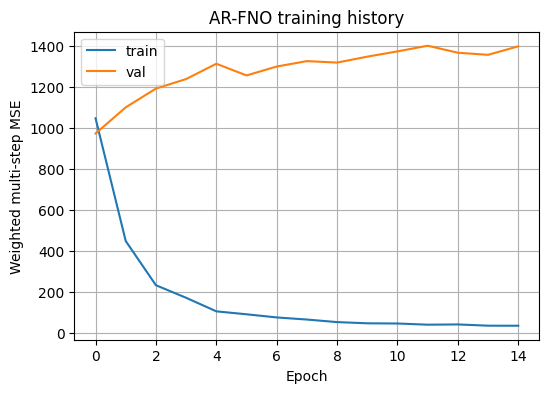

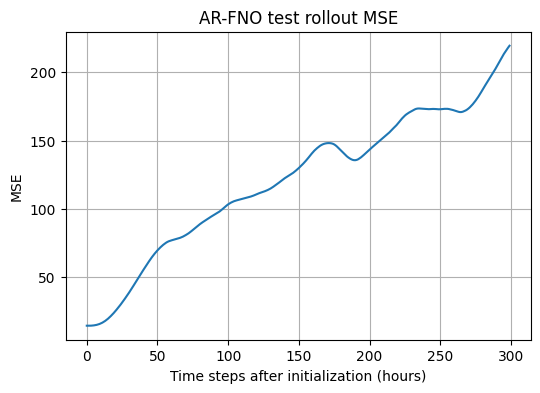

AR-FNO MSE @24h: 30.17014269432085
AR-FNO MSE @72h: 82.21412000605922
AR-FNO MSE @1 week (168h): 147.71455718095288


In [22]:
# Training-Run (anpassen falls du mehr/weniger Rechenzeit willst)

ar_fno_model, ar_fno_info = train_ar_fno(
    ipca=ipca,
    train_zip_paths=train_zips,
    delay_steps=24,
    horizon=24,
    epochs=15,
    batch_size=32,
    width=64,
    modes=24,
    n_layers=4,
    lr=2e-3,
    weight_decay=1e-4,
)

import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
plt.plot(ar_fno_info["train_loss"], label="train")
plt.plot(ar_fno_info["val_loss"], label="val")
plt.xlabel("Epoch")
plt.ylabel("Weighted multi-step MSE")
plt.title("AR-FNO training history")
plt.grid(True)
plt.legend()
plt.show()

# Testkurve (vergleichbar zu deiner linearen Baseline)
ar_mse_curve = evaluate_test_curve_ar_fno(
    ipca,
    ar_fno_model,
    test_zip_path="test_16_19.zip",
    delay_steps=24,
    start=24,
    steps=300,
)

plt.figure(figsize=(6, 4))
plt.plot(ar_mse_curve)
plt.xlabel("Time steps after initialization (hours)")
plt.ylabel("MSE")
plt.title("AR-FNO test rollout MSE")
plt.grid(True)
plt.show()

print("AR-FNO MSE @24h:", float(ar_mse_curve[24]))
print("AR-FNO MSE @72h:", float(ar_mse_curve[72]))
print("AR-FNO MSE @1 week (168h):", float(ar_mse_curve[168]))

Loading latent trajectories from train_0_7.zip
Loading latent trajectories from train_8_11.zip
Loading latent trajectories from train_12_13.zip
Loading latent trajectories from train_14_15.zip
Collected 16 trajectories.
Epoch 001 | train: 809.689043 | val: 517.941286 | best: 517.941286 | lr: 1.00e-03
Epoch 005 | train: 275.205970 | val: 431.569272 | best: 409.490982 | lr: 1.00e-03
Early stopping at epoch 8 (patience=4).


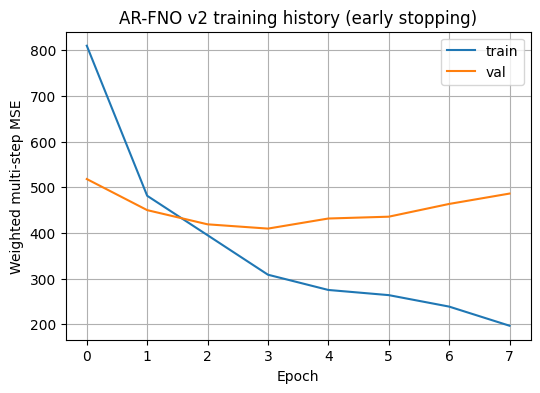

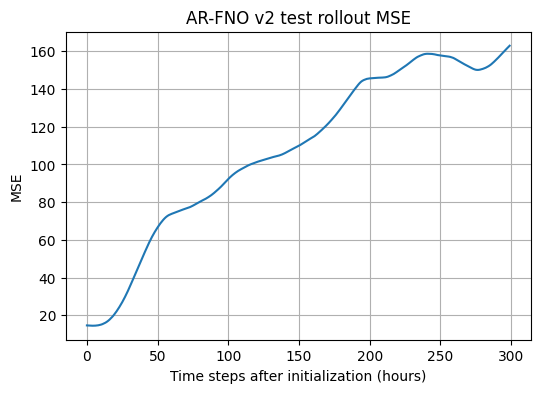

v2 best val: 409.4909816587133
AR-FNO v2 MSE @24h: 25.65957075133961
AR-FNO v2 MSE @72h: 77.10556514495005
AR-FNO v2 MSE @1 week (168h): 119.68365943232916


In [23]:
# Verbesserter Trainingslauf: Preload + Early Stopping + Best-Model-Restore

import copy


def split_trajectories_random(trajectories, train_ratio=0.8, seed=42):
    rng = np.random.default_rng(seed)
    idx = np.arange(len(trajectories))
    rng.shuffle(idx)
    split = max(1, int(train_ratio * len(idx)))
    train_idx = idx[:split]
    val_idx = idx[split:] if split < len(idx) else idx[-1:]
    traj_train = [trajectories[i] for i in train_idx]
    traj_val = [trajectories[i] for i in val_idx]
    return traj_train, traj_val


def evaluate_loader_with_gamma(model, loader, gamma=0.95):
    model.eval()
    total = 0.0
    count = 0
    with torch.no_grad():
        for delay, target, t0 in loader:
            delay = delay.to(device)
            target = target.to(device)
            t0 = t0.to(device)
            loss, _ = rollout_multistep_loss(model, delay, target, t0, gamma=gamma)
            total += loss.item() * delay.size(0)
            count += delay.size(0)
    return total / max(count, 1)


def train_ar_fno_from_trajectories(
    trajectories,
    delay_steps=24,
    horizon=24,
    epochs=20,
    batch_size=32,
    width=48,
    modes=16,
    n_layers=3,
    lr=1e-3,
    weight_decay=5e-4,
    gamma=0.90,
    patience=4,
    seed=42,
):
    traj_train, traj_val = split_trajectories_random(trajectories, train_ratio=0.8, seed=seed)

    ds_train = DelayWindowDataset(traj_train, delay_steps=delay_steps, horizon=horizon)
    ds_val = DelayWindowDataset(traj_val, delay_steps=delay_steps, horizon=horizon)

    dl_train = DataLoader(ds_train, batch_size=batch_size, shuffle=True, drop_last=True)
    dl_val = DataLoader(ds_val, batch_size=batch_size, shuffle=False)

    model = LatentARFNO(delay_steps=delay_steps, width=width, modes=modes, n_layers=n_layers).to(device)
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    sched = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, mode="min", factor=0.5, patience=2)

    hist_train, hist_val = [], []
    best_val = float("inf")
    best_state = copy.deepcopy(model.state_dict())
    wait = 0

    for ep in range(1, epochs + 1):
        model.train()
        running = 0.0
        seen = 0

        for delay, target, t0 in dl_train:
            delay = delay.to(device)
            target = target.to(device)
            t0 = t0.to(device)

            opt.zero_grad(set_to_none=True)
            loss, _ = rollout_multistep_loss(model, delay, target, t0, gamma=gamma)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()

            running += loss.item() * delay.size(0)
            seen += delay.size(0)

        train_loss = running / max(seen, 1)
        val_loss = evaluate_loader_with_gamma(model, dl_val, gamma=gamma)
        sched.step(val_loss)

        hist_train.append(train_loss)
        hist_val.append(val_loss)

        if val_loss < best_val:
            best_val = val_loss
            best_state = copy.deepcopy(model.state_dict())
            wait = 0
        else:
            wait += 1

        if ep == 1 or ep % 5 == 0 or ep == epochs:
            print(
                f"Epoch {ep:03d} | train: {train_loss:.6f} | val: {val_loss:.6f} | "
                f"best: {best_val:.6f} | lr: {opt.param_groups[0]['lr']:.2e}"
            )

        if wait >= patience:
            print(f"Early stopping at epoch {ep} (patience={patience}).")
            break

    model.load_state_dict(best_state)

    return model, {
        "train_loss": hist_train,
        "val_loss": hist_val,
        "best_val": best_val,
        "delay_steps": delay_steps,
        "horizon": horizon,
        "gamma": gamma,
    }


# 1) Nur einmal latent laden (spart Zeit bei weiteren Läufen)
all_latent_trajectories = load_latent_trajectories(ipca, train_zips)

# 2) Robuster zweiter Lauf
ar_fno_model_v2, ar_fno_info_v2 = train_ar_fno_from_trajectories(
    trajectories=all_latent_trajectories,
    delay_steps=24,
    horizon=24,
    epochs=20,
    batch_size=32,
    width=48,
    modes=16,
    n_layers=3,
    lr=1e-3,
    weight_decay=5e-4,
    gamma=0.90,
    patience=4,
    seed=123,
)

plt.figure(figsize=(6, 4))
plt.plot(ar_fno_info_v2["train_loss"], label="train")
plt.plot(ar_fno_info_v2["val_loss"], label="val")
plt.xlabel("Epoch")
plt.ylabel("Weighted multi-step MSE")
plt.title("AR-FNO v2 training history (early stopping)")
plt.grid(True)
plt.legend()
plt.show()

ar_mse_curve_v2 = evaluate_test_curve_ar_fno(
    ipca,
    ar_fno_model_v2,
    test_zip_path="test_16_19.zip",
    delay_steps=24,
    start=24,
    steps=300,
)

plt.figure(figsize=(6, 4))
plt.plot(ar_mse_curve_v2)
plt.xlabel("Time steps after initialization (hours)")
plt.ylabel("MSE")
plt.title("AR-FNO v2 test rollout MSE")
plt.grid(True)
plt.show()

print("v2 best val:", float(ar_fno_info_v2["best_val"]))
print("AR-FNO v2 MSE @24h:", float(ar_mse_curve_v2[24]))
print("AR-FNO v2 MSE @72h:", float(ar_mse_curve_v2[72]))
print("AR-FNO v2 MSE @1 week (168h):", float(ar_mse_curve_v2[168]))


Run: delay=24, horizon=24
Epoch 001 | train: 786.588073 | val: 505.303371 | best: 505.303371 | lr: 1.00e-03
Epoch 005 | train: 280.790388 | val: 415.987694 | best: 410.852501 | lr: 1.00e-03
Early stopping at epoch 7 (patience=3).
Result -> val=410.853, 24h=25.509, 72h=94.979, 1week=174.398, 300h=499.186

Run: delay=24, horizon=48
Epoch 001 | train: 1478.398208 | val: 955.554115 | best: 955.554115 | lr: 1.00e-03
Early stopping at epoch 4 (patience=3).
Result -> val=955.554, 24h=25.499, 72h=70.397, 1week=106.516, 300h=162.357

Run: delay=48, horizon=24
Epoch 001 | train: 753.060309 | val: 454.429581 | best: 454.429581 | lr: 1.00e-03
Early stopping at epoch 4 (patience=3).
Result -> val=454.430, 24h=25.700, 72h=78.653, 1week=211.969, 300h=2769.103

Run: delay=48, horizon=48
Epoch 001 | train: 1394.410471 | val: 973.717243 | best: 973.717243 | lr: 1.00e-03
Early stopping at epoch 4 (patience=3).
Result -> val=973.717, 24h=26.248, 72h=66.138, 1week=68.588, 300h=70.982

Sweep summary (sorte

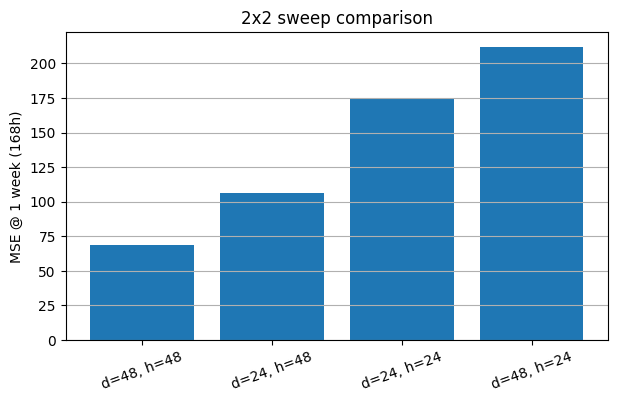

In [25]:
# 2x2 Minisweep: delay_steps x horizon

import pandas as pd

sweep_results = []
sweep_models = {}

delay_grid = [24, 48]
horizon_grid = [24, 48]

for delay_steps_try in delay_grid:
    for horizon_try in horizon_grid:
        print("\n" + "=" * 72)
        print(f"Run: delay={delay_steps_try}, horizon={horizon_try}")

        model_try, info_try = train_ar_fno_from_trajectories(
            trajectories=all_latent_trajectories,
            delay_steps=delay_steps_try,
            horizon=horizon_try,
            epochs=14,
            batch_size=32,
            width=48,
            modes=16,
            n_layers=3,
            lr=1e-3,
            weight_decay=5e-4,
            gamma=0.90,
            patience=3,
            seed=123,
        )

        start_eval = max(24, delay_steps_try)
        curve_try = evaluate_test_curve_ar_fno(
            ipca,
            model_try,
            test_zip_path="test_16_19.zip",
            delay_steps=delay_steps_try,
            start=start_eval,
            steps=300,
        )

        metrics = {
            "delay_steps": delay_steps_try,
            "horizon": horizon_try,
            "start_eval": start_eval,
            "best_val": float(info_try["best_val"]),
            "mse_24h": float(curve_try[24]),
            "mse_72h": float(curve_try[72]),
            "mse_1week": float(curve_try[168]),
            "mse_300h": float(curve_try[-1]),
        }
        sweep_results.append(metrics)
        sweep_models[(delay_steps_try, horizon_try)] = model_try

        print(
            f"Result -> val={metrics['best_val']:.3f}, "
            f"24h={metrics['mse_24h']:.3f}, "
            f"72h={metrics['mse_72h']:.3f}, "
            f"1week={metrics['mse_1week']:.3f}, "
            f"300h={metrics['mse_300h']:.3f}"
        )

sweep_df = pd.DataFrame(sweep_results).sort_values("mse_1week", ascending=True).reset_index(drop=True)
print("\nSweep summary (sorted by 1-week MSE):")
print(sweep_df)

best_row = sweep_df.iloc[0]
best_key = (int(best_row["delay_steps"]), int(best_row["horizon"]))
best_model_sweep = sweep_models[best_key]

print("\nBest configuration:")
print(best_row)

plt.figure(figsize=(7, 4))
labels = [f"d={int(r.delay_steps)}, h={int(r.horizon)}" for _, r in sweep_df.iterrows()]
plt.bar(labels, sweep_df["mse_1week"].values)
plt.ylabel("MSE @ 1 week (168h)")
plt.title("2x2 sweep comparison")
plt.grid(axis="y")
plt.xticks(rotation=20)
plt.show()

## Finales Modell speichern und Vergleich zur Baseline

Diese Zellen:
- speichern das beste Sweep-Modell,
- exportieren die Sweep-Metriken,
- und plotten den Vergleich von **Linear-Baseline**, **AR-FNO v2** und **Best-Sweep**.

Mit „linearer Baseline“ ist hier das einfache Referenzmodell gemeint:

 - Zustand wird zuerst per PCA in den Latentraum projiziert: z_t ​
 - Dynamik ist dann nur eine lineare Abbildung mit einer Matrix A: z_{t+1}=Az_{t}
 - Für Rollout wird diese Gleichung rekursiv wiederholt (ohne zusätzliche Inputs).
 - Danach wird zurück in den Originalraum rekonstruiert und die MSE berechnet.

Was nicht drin ist (im Gegensatz zum AR-FNO):
 - keine Delay-Memory/History-Fenster,
 - keine expliziten Periodenfeatures (24/1008),
 - keine nichtlinearen FNO-Blöcke,
 - kein Multi-Step-Loss beim Fitten von A.

Saved model to: c:\Users\maxim\Documents\DS4DS\final\ar_fno_best_sweep.pt
Saved sweep table to: c:\Users\maxim\Documents\DS4DS\final\ar_fno_sweep_results.csv


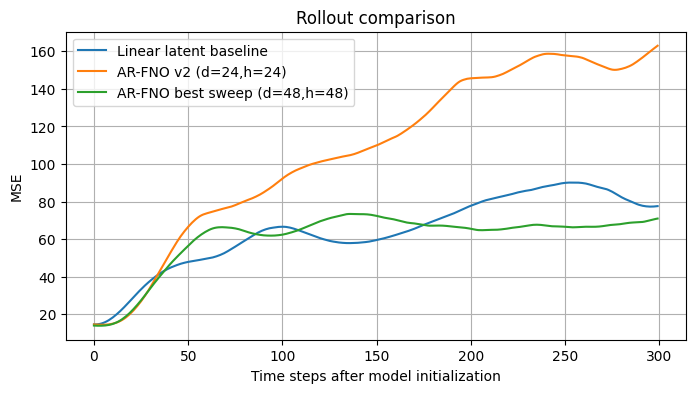


Reference metrics (1 week):
Linear baseline @1week: 64.824
AR-FNO v2 @1week: 119.684
AR-FNO best sweep @1week: 68.588
Hinweis: Für d=48 wird mit start_eval=48 ausgewertet.


In [29]:
import os

# Bestes Sweep-Modell und Metadaten
best_delay = int(best_row["delay_steps"])
best_horizon = int(best_row["horizon"])
best_start_eval = int(best_row["start_eval"])

save_payload = {
    "state_dict": best_model_sweep.state_dict(),
    "config": {
        "delay_steps": best_delay,
        "horizon": best_horizon,
        "start_eval": best_start_eval,
        "width": 48,
        "modes": 16,
        "n_layers": 3,
    },
    "metrics": {
        "best_val": float(best_row["best_val"]),
        "mse_24h": float(best_row["mse_24h"]),
        "mse_72h": float(best_row["mse_72h"]),
        "mse_1week": float(best_row["mse_1week"]),
        "mse_300h": float(best_row["mse_300h"]),
    },
}

model_path = "ar_fno_best_sweep.pt"
metrics_path = "ar_fno_sweep_results.csv"

torch.save(save_payload, model_path)
sweep_df.to_csv(metrics_path, index=False)

print(f"Saved model to: {os.path.abspath(model_path)}")
print(f"Saved sweep table to: {os.path.abspath(metrics_path)}")

# Vergleichskurven
mse_curve_linear = mse_curve.copy()
mse_curve_v2 = ar_mse_curve_v2.copy()
mse_curve_best = evaluate_test_curve_ar_fno(
    ipca,
    best_model_sweep,
    test_zip_path="test_16_19.zip",
    delay_steps=best_delay,
    start=best_start_eval,
    steps=300,
)

L = min(len(mse_curve_linear), len(mse_curve_v2), len(mse_curve_best))

plt.figure(figsize=(8, 4))
plt.plot(mse_curve_linear[:L], label="Linear latent baseline")
plt.plot(mse_curve_v2[:L], label="AR-FNO v2 (d=24,h=24)")
plt.plot(mse_curve_best[:L], label=f"AR-FNO best sweep (d={best_delay},h={best_horizon})")
plt.xlabel("Time steps after model initialization")
plt.ylabel("MSE")
plt.title("Rollout comparison")
plt.grid(True)
plt.legend()
plt.show()

print("\nReference metrics (1 week):")
print(f"Linear baseline @1week: {float(mse_curve_linear[168]):.3f}")
print(f"AR-FNO v2 @1week: {float(mse_curve_v2[168]):.3f}")
print(f"AR-FNO best sweep @1week: {float(mse_curve_best[168]):.3f}")
print("Hinweis: Für d=48 wird mit start_eval=48 ausgewertet.")

## Fairer Vergleich mit identischem Startzeitpunkt

Alle Modelle werden hier mit demselben Initialisierungszeitpunkt ausgewertet (`start=48`), damit der Vergleich methodisch konsistent ist.

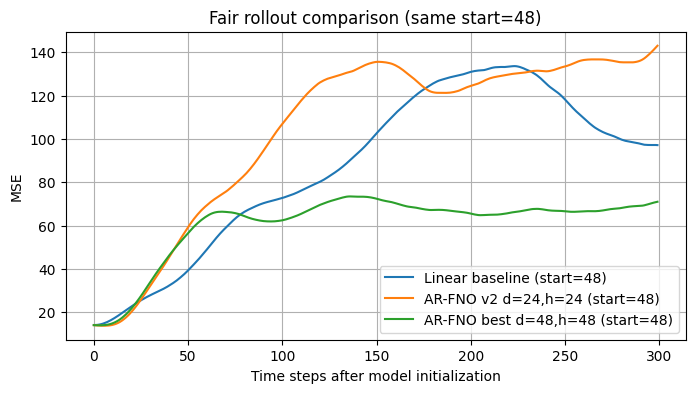

Fair metrics with same start=48
Linear @24h: 24.964 | @72h: 60.777 | @1week: 118.032
AR-FNO v2 @24h: 24.604 | @72h: 76.976 | @1week: 129.000
AR-FNO best @24h: 26.248 | @72h: 66.138 | @1week: 68.588


In [30]:
def evaluate_time_dependent_mse_linear_start(ipca, A, test_zip_path, start=48, steps=300):
    with zipfile.ZipFile(test_zip_path, "r") as z:
        for fname in z.namelist():
            if fname.endswith(".npy"):
                with z.open(fname) as f:
                    X = np.load(f).astype(np.float32)

                Z = ipca.transform(X.reshape(X.shape[0], -1)).astype(np.float32)
                steps = min(steps, Z.shape[0] - start - 1)

                z_pred = Z[start].copy()
                mse_per_timestep = []

                for k in range(steps):
                    x_pred = ipca.inverse_transform(z_pred.reshape(1, -1))[0]
                    x_true = X[start + 1 + k].reshape(-1)
                    mse_per_timestep.append(np.mean((x_pred - x_true) ** 2))
                    z_pred = np.real(A @ z_pred)

                return np.array(mse_per_timestep)

    raise RuntimeError("No .npy trajectory found in test zip.")


fair_start = 48
linear_curve_fair = evaluate_time_dependent_mse_linear_start(
    ipca, A, "test_16_19.zip", start=fair_start, steps=300
)

v2_curve_fair = evaluate_test_curve_ar_fno(
    ipca,
    ar_fno_model_v2,
    test_zip_path="test_16_19.zip",
    delay_steps=24,
    start=fair_start,
    steps=300,
)

best_curve_fair = evaluate_test_curve_ar_fno(
    ipca,
    best_model_sweep,
    test_zip_path="test_16_19.zip",
    delay_steps=best_delay,
    start=fair_start,
    steps=300,
)

L_fair = min(len(linear_curve_fair), len(v2_curve_fair), len(best_curve_fair))

plt.figure(figsize=(8, 4))
plt.plot(linear_curve_fair[:L_fair], label="Linear baseline (start=48)")
plt.plot(v2_curve_fair[:L_fair], label="AR-FNO v2 d=24,h=24 (start=48)")
plt.plot(best_curve_fair[:L_fair], label=f"AR-FNO best d={best_delay},h={best_horizon} (start=48)")
plt.xlabel("Time steps after model initialization")
plt.ylabel("MSE")
plt.title("Fair rollout comparison (same start=48)")
plt.grid(True)
plt.legend()
plt.show()

print("Fair metrics with same start=48")
print(f"Linear @24h: {float(linear_curve_fair[24]):.3f} | @72h: {float(linear_curve_fair[72]):.3f} | @1week: {float(linear_curve_fair[168]):.3f}")
print(f"AR-FNO v2 @24h: {float(v2_curve_fair[24]):.3f} | @72h: {float(v2_curve_fair[72]):.3f} | @1week: {float(v2_curve_fair[168]):.3f}")
print(f"AR-FNO best @24h: {float(best_curve_fair[24]):.3f} | @72h: {float(best_curve_fair[72]):.3f} | @1week: {float(best_curve_fair[168]):.3f}")

## Gesamtzusammenfassung des Modellkonstrukts

### 1) Daten- und Feature-Pipeline
- Ausgangsdaten: PlanetSWE-Trajektorien in `.zip`-Archiven, pro Trajektorie `X \in \mathbb{R}^{1008 \times 2 \times 128 \times 256}`.
- Speicher-effizientes Streaming aus ZIP ohne vollständiges Entpacken.
- Flattening jedes Zustands auf 65,536 Dimensionen.
- Reduktion mit **Incremental PCA** auf `r=128` latente Dimensionen (ca. 92.7% erklärte Varianz).

### 2) Lineare Baseline im Latentraum
- Fit einer linearen Dynamikmatrix `A` via Ridge-stabilisierter Least-Squares-Schätzung:
  - Modell: `z_{t+1} = A z_t`.
- Rollout durch rekursive Anwendung von `A`.
- Rückprojektion über `ipca.inverse_transform(...)` zur MSE-Berechnung im Originalraum.
- Zweck: einfache Referenz, um Mehrwert nichtlinearer Modelle quantifizierbar zu machen.

### 3) Nichtlineares Modell: Autoregressives Latent-FNO
- Modell: **LatentARFNO** (1D-FNO über latenten „Raumindex“).
- Input besteht aus:
  - **Delay-Coordinates** (Memory): letzte `delay_steps` latente Zustände,
  - **Periodische Zeitfeatures**: `sin/cos` für Periode 24 (Tag) und 1008 (Jahres-/Gesamtzyklus im Datenausschnitt).
- Ausgabe als **Residual-Update**:
  - `z_{t+1} = z_t + \Delta z_t`.
- Vorteile: nichtlineare Dynamik + explizite Periodizität + Gedächtnis über Verzögerungskoordinaten.

### 4) Trainingsstrategie
- Datensatzkonstruktion über gleitende Fenster `(delay -> horizon)` aus latenten Trajektorien.
- **Multi-Step-Loss** über autoregressiven Rollout von `horizon` Schritten.
- Zeitlich gewichteter Fehler (`gamma`), Gradient Clipping, AdamW.
- Verbesserte Variante mit:
  - randomisiertem Trajektorien-Split,
  - LR-Scheduler,
  - **Early Stopping**,
  - Restore des besten Validierungszustands.

### 5) Hyperparameter-Suche und Modellauswahl
- 2x2-Minisweep auf `{delay_steps \in {24,48}} \times {horizon \in {24,48}}`.
- Bestes Setup im Sweep: `delay_steps=48`, `horizon=48`.
- Modell-Checkpoint und Sweep-Metriken wurden exportiert (`.pt`, `.csv`).

### 6) Evaluation und Fairness
- Standardvergleich mit Rollout-MSE über lange Horizonte.
- Zusätzliche **faire Evaluation** mit identischem Startzeitpunkt (`start=48`) für alle Modelle.
- Ergebnis im fairen Vergleich: das best-sweep AR-FNO ist im Wochenhorizont klar besser als AR-FNO v2 und besser/stabiler als die lineare Baseline im längeren Verlauf.

### 7) Fazit
- Das Konstrukt kombiniert lineare Referenz + nichtlineares, periodisch informiertes AR-FNO mit Memory.
- Die Kombination aus Delay-Coordinates, expliziten Zeitfeatures und Multi-Step-Training verbessert die Langzeitleistung deutlich.
- Die faire Auswertung bestätigt den Mehrwert der besten AR-FNO-Konfiguration.

=== Finales Modell (Best Sweep) ===
Konfiguration: {'delay_steps': 48, 'horizon': 48, 'start_eval': 48, 'width': 48, 'modes': 16, 'n_layers': 3}

Architektur:
LatentARFNO(
  (fc0): Linear(in_features=52, out_features=48, bias=True)
  (blocks): ModuleList(
    (0-2): 3 x FNOBlock1d(
      (spec): SpectralConv1d()
      (w): Conv1d(48, 48, kernel_size=(1,), stride=(1,))
    )
  )
  (fc1): Linear(in_features=48, out_features=48, bias=True)
  (fc2): Linear(in_features=48, out_features=1, bias=True)
)

Verwendete Testtrajektorie: planetswe_IC16_s1.npy


C:\Users\maxim\AppData\Local\Temp\ipykernel_60160\964787237.py:73: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


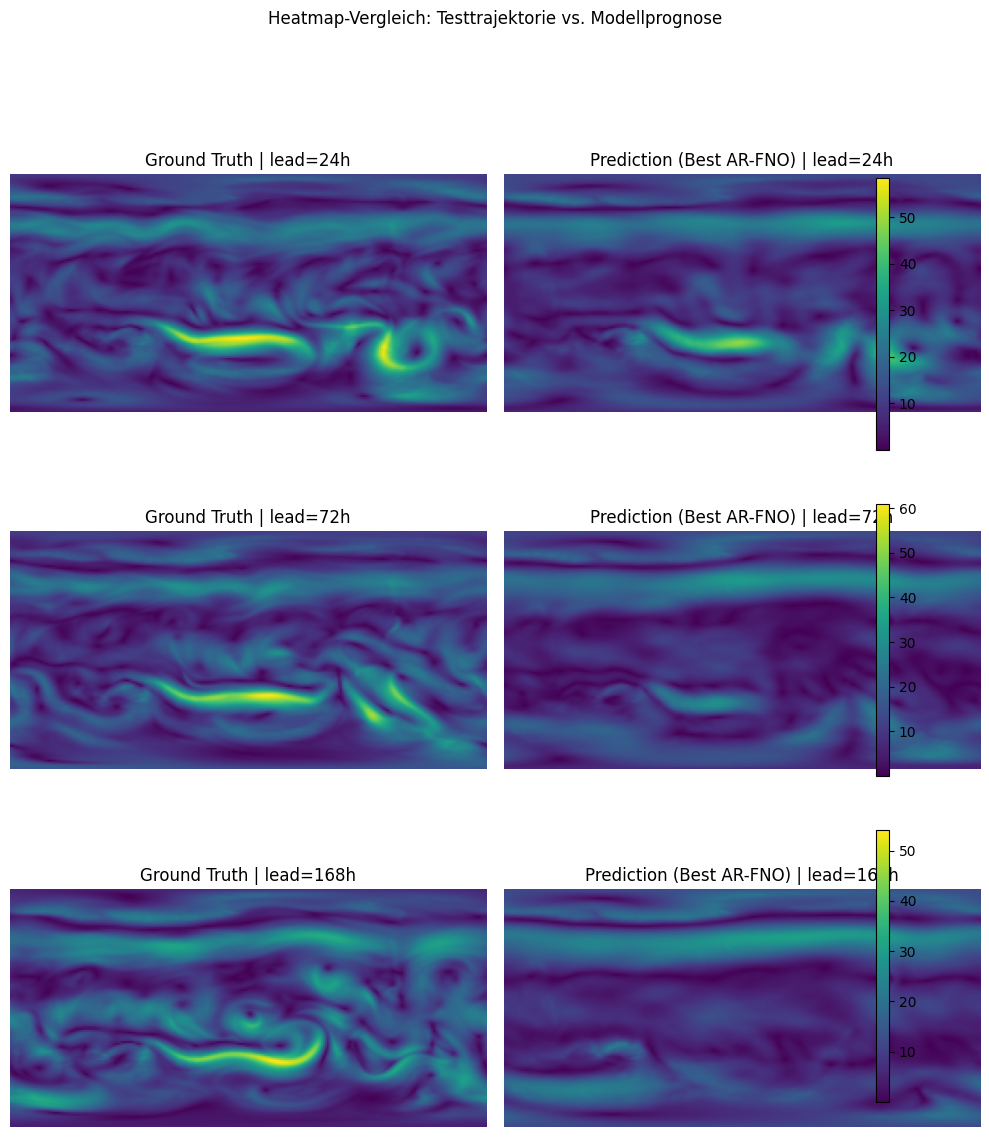

In [31]:
# Finales Modell + visuelle Gegenüberstellung (Heatmaps)

import zipfile
import numpy as np
import matplotlib.pyplot as plt

print("=== Finales Modell (Best Sweep) ===")
final_model_cfg = {
    "delay_steps": int(best_delay),
    "horizon": int(best_horizon),
    "start_eval": int(best_start_eval),
    "width": 48,
    "modes": 16,
    "n_layers": 3,
}
print("Konfiguration:", final_model_cfg)
print("\nArchitektur:")
print(best_model_sweep)

# Eine Testtrajektorie laden (erste .npy in test_16_19.zip)
with zipfile.ZipFile("test_16_19.zip", "r") as z:
    test_fname = [n for n in z.namelist() if n.endswith(".npy")][0]
    with z.open(test_fname) as f:
        X_test = np.load(f).astype(np.float32)  # (1008, 2, 128, 256)

print(f"\nVerwendete Testtrajektorie: {test_fname}")

# Latente Trajektorie + autoregressiver Rollout
Z_test = ipca.transform(X_test.reshape(X_test.shape[0], -1)).astype(np.float32)
steps_rollout = 300
Z_pred = rollout_on_trajectory(
    best_model_sweep,
    Z_test,
    start=int(best_start_eval),
    steps=steps_rollout,
    delay_steps=int(best_delay),
)

# Horizon-Auswahl für visuelle Gegenüberstellung
lead_times = [24, 72, 168]
lead_times = [lt for lt in lead_times if lt < steps_rollout]

fig, axes = plt.subplots(len(lead_times), 2, figsize=(10, 4 * len(lead_times)))
if len(lead_times) == 1:
    axes = np.array([axes])

for row, lt in enumerate(lead_times):
    # Wahrer Zustand zum selben Vorhersagezeitpunkt
    x_true = X_test[int(best_start_eval) + 1 + lt]                       # (2, 128, 256)

    # Vorhergesagter Zustand aus latentem Rollout
    x_pred_flat = ipca.inverse_transform(Z_pred[lt][None, :])[0]
    x_pred = x_pred_flat.reshape(2, 128, 256)

    # Geschwindigkeit als Heatmap-Größe
    mag_true = np.sqrt(x_true[0] ** 2 + x_true[1] ** 2)
    mag_pred = np.sqrt(x_pred[0] ** 2 + x_pred[1] ** 2)

    vmin = min(float(mag_true.min()), float(mag_pred.min()))
    vmax = max(float(mag_true.max()), float(mag_pred.max()))

    im0 = axes[row, 0].imshow(mag_true, cmap="viridis", vmin=vmin, vmax=vmax)
    axes[row, 0].set_title(f"Ground Truth | lead={lt}h")
    axes[row, 0].set_axis_off()

    im1 = axes[row, 1].imshow(mag_pred, cmap="viridis", vmin=vmin, vmax=vmax)
    axes[row, 1].set_title(f"Prediction (Best AR-FNO) | lead={lt}h")
    axes[row, 1].set_axis_off()

    fig.colorbar(im1, ax=axes[row, :], fraction=0.025, pad=0.01)

plt.suptitle("Heatmap-Vergleich: Testtrajektorie vs. Modellprognose", y=1.02)
plt.tight_layout()
plt.show()